<a href="https://colab.research.google.com/github/navv2/BigData_computing_2026/blob/main/%E1%84%8C%E1%85%AE%E1%86%BC%E1%84%80%E1%85%A1%E1%86%AB%E1%84%80%E1%85%A9%E1%84%89%E1%85%A1_%E1%84%91%E1%85%B3%E1%84%85%E1%85%A9%E1%84%80%E1%85%B3%E1%84%85%E1%85%A2%E1%84%86%E1%85%B5%E1%86%BC_%E1%84%80%E1%85%AA%E1%84%8C%E1%85%A6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  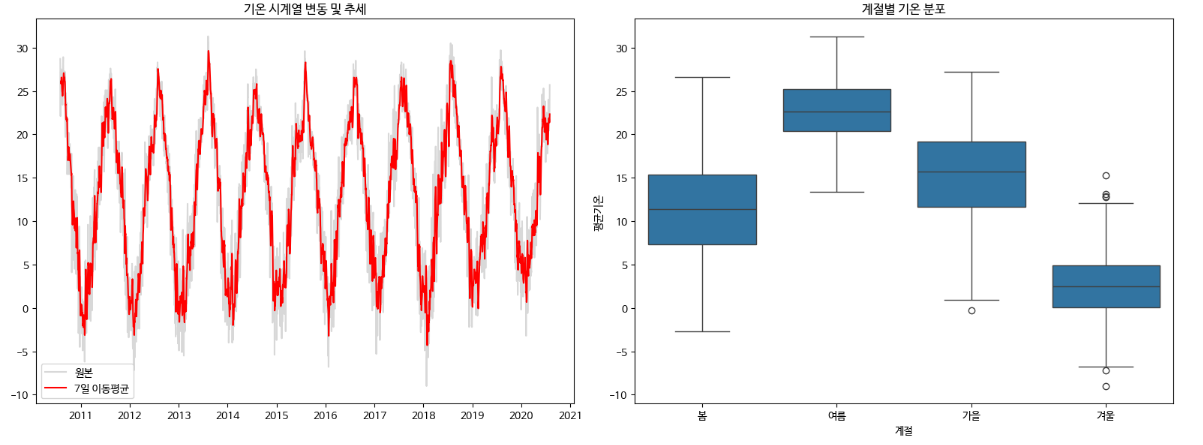

  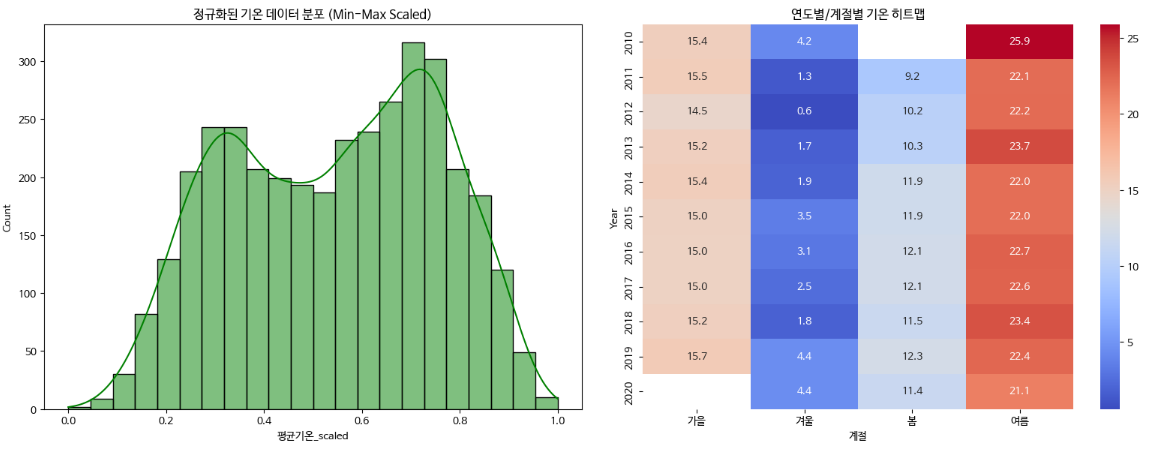



✅ 환경 설정 및 한글 폰트 로드 완료


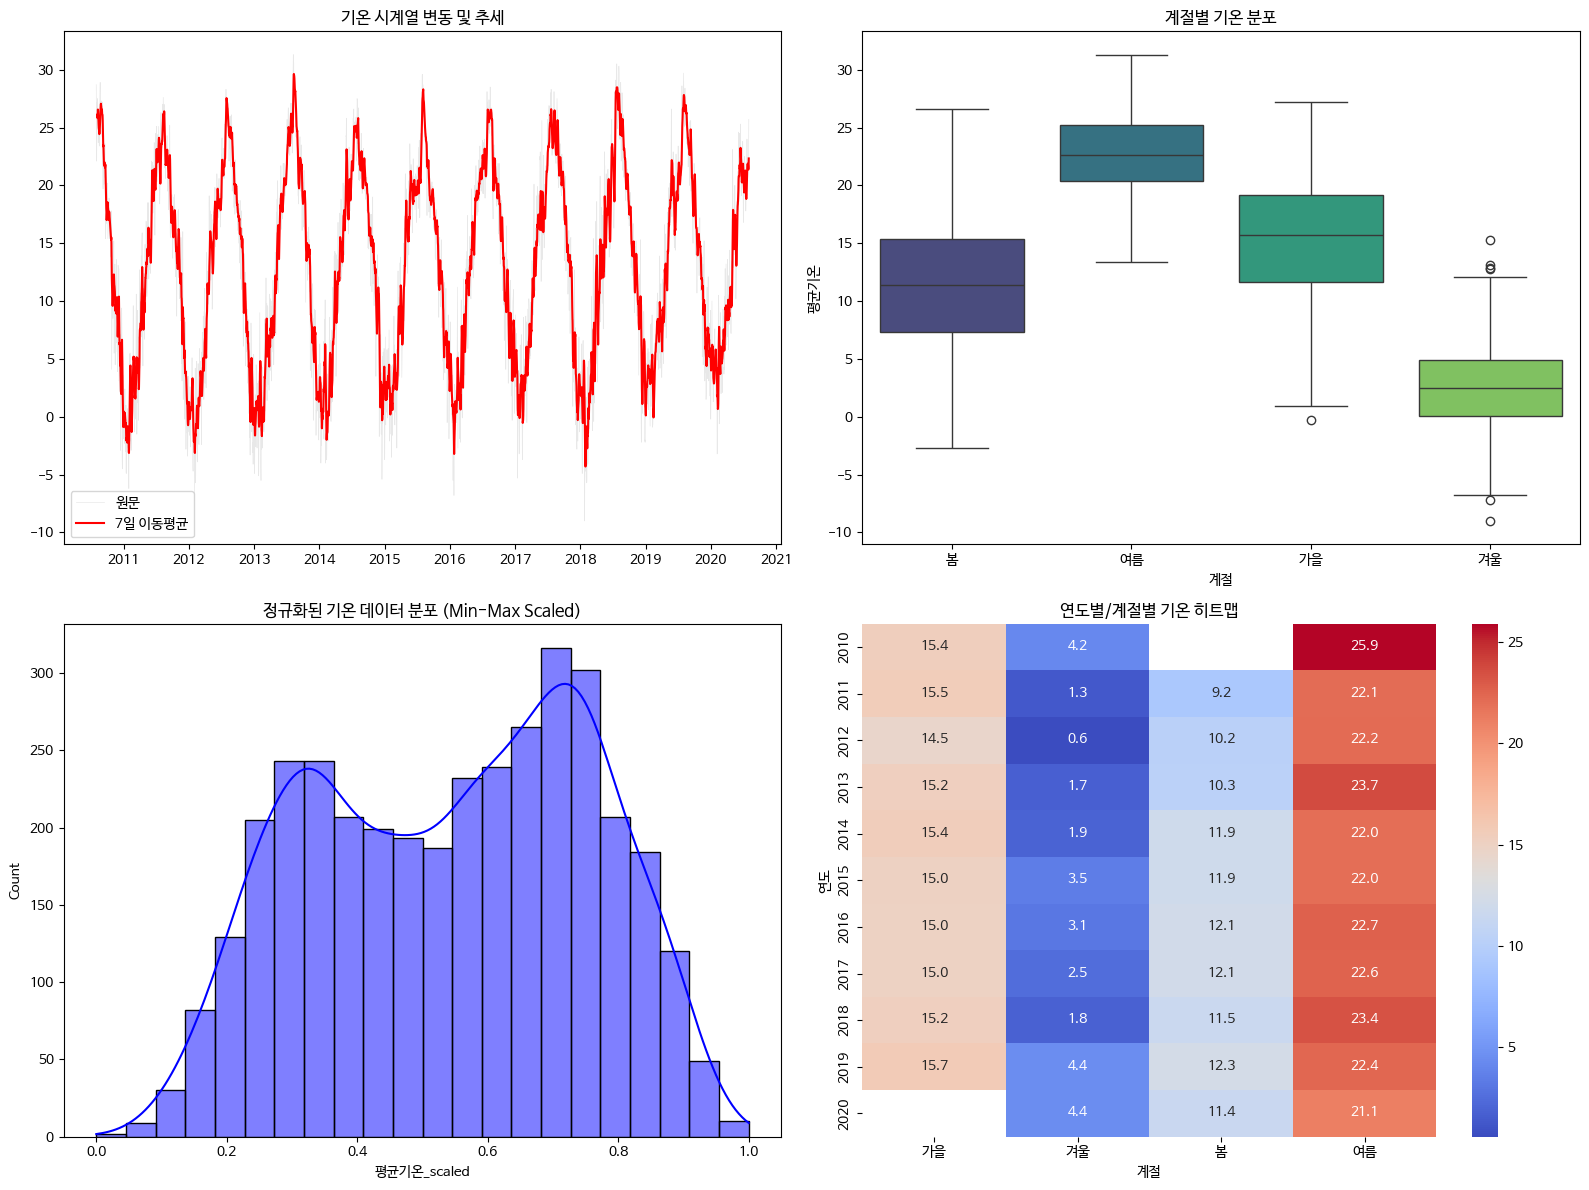

[weather_analysis_report.xlsx] 파일이 생성되었습니다.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()


def load_data(url):
    """데이터 수집 함수"""
    df = pd.read_csv(url, encoding='cp949')
    return df

def preprocess_weather(df):
    """시계열 변환, 계절 분류, 정규화 수행"""
    # 1. 시계열 변환
    df['일시'] = pd.to_datetime(df['일시'])
    df = df.set_index('일시')

    # 2. 이동 평균 생성
    df['7일이동평균'] = df['평균기온'].rolling(window=7).mean()

    # 3. 계절 및 연도 정보 추가
    df['연도'] = df.index.year
    df['월'] = df.index.month
    def get_season(month):
        if month in [3, 4, 5]: return '봄'
        elif month in [6, 7, 8]: return '여름'
        elif month in [9, 10, 11]: return '가을'
        else: return '겨울'
    df['계절'] = df['월'].apply(get_season)

    # 4. 정규화 (Min-Max Scaling)
    min_val = df['평균기온'].min()
    max_val = df['평균기온'].max()
    df['평균기온_scaled'] = (df['평균기온'] - min_val) / (max_val - min_val)

    return df

def create_visualizations(df):
    """4분할 그래프 생성 (시계열, 박스플롯, 히스토그램, 히트맵)"""
    # 서브플롯 설정 (2행 2열)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    # 1. 기온 시계열 변동 및 추세 (Left-Top)
    axes[0, 0].plot(df.index, df['평균기온'], color='lightgray', label='원문', alpha=0.5, linewidth=0.5)
    axes[0, 0].plot(df.index, df['7일이동평균'], color='red', label='7일 이동평균', linewidth=1.5)
    axes[0, 0].set_title("기온 시계열 변동 및 추세")
    axes[0, 0].legend()

    # 2. 계절별 기온 분포 - Box Plot (Right-Top)
    # 순서 보장을 위해 범주형 설정
    season_order = ['봄', '여름', '가을', '겨울']
    sns.boxplot(x='계절', y='평균기온', data=df, order=season_order, palette='viridis', ax=axes[0, 1])
    axes[0, 1].set_title("계절별 기온 분포")

    # 3. 정규화된 기온 데이터 분포 - Histogram/KDE (Left-Bottom)
    sns.histplot(df['평균기온_scaled'].dropna(), kde=True, color='forestgreen', ax=axes[1, 0])
    axes[1, 0].set_title("정규화된 기온 데이터 분포 (Min-Max Scaled)")

    # 4. 연도별/계절별 기온 히트맵 (Right-Bottom)
    # 히트맵용 피벗 테이블 생성
    pivot_df = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')
    pivot_df = pivot_df[['가을', '겨울', '봄', '여름']] # 이미지와 동일한 순서 정렬

    sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title("연도별/계절별 기온 히트맵")

    plt.tight_layout()
    plt.show()

def save_to_excel(df, filename):
    """분석 결과를 엑셀 파일의 시트별로 저장"""
    # 시트별 데이터 준비
    seasonal_stats = df.groupby('계절')['평균기온'].describe()
    pivot_table = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')

    with pd.ExcelWriter(filename) as writer:
        df.to_excel(writer, sheet_name='전처리_전체데이터')
        seasonal_stats.to_excel(writer, sheet_name='계절별_요약통계')
        pivot_table.to_excel(writer, sheet_name='연도계절별_피벗')
    print(f"[{filename}] 파일이 생성되었습니다.")

def main():
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

    # 1. 데이터 로드
    df_raw = load_data(url)

    # 2. 전처리 및 스케일링
    df_processed = preprocess_weather(df_raw)

    # 3. 시각화 (이미지의 4개 그래프 생성)
    create_visualizations(df_processed)

    # 4. 엑셀 저장
    save_to_excel(df_processed, 'weather_analysis_report.xlsx')

if __name__ == "__main__":
    main()